**ANN - Classifier**

In [1]:
# Import libraries
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np 
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split

In [2]:
# Reading data 
data = pd.read_csv("C:/MAFAS/APU/CT046-3-M-AML/CT046 - LABS/Python LAB MATERIALS/Lab 9 - Neural Network/Iris.csv")
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa


**Visualisation of the dataset**

The coding below shows the visualisation of the dataset in order to understand the data more. It can be seen that every species of the Iris can be segregated into different regions to be predicted.

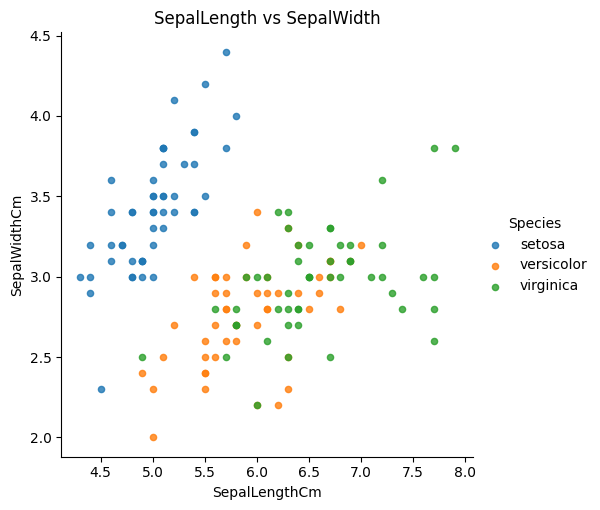

In [3]:
sns.lmplot(x = 'SepalLengthCm', y = 'SepalWidthCm', data = data, fit_reg = False, hue = "Species", scatter_kws = {"marker": "D", "s": 20})
plt.title('SepalLength vs SepalWidth')
plt.show()

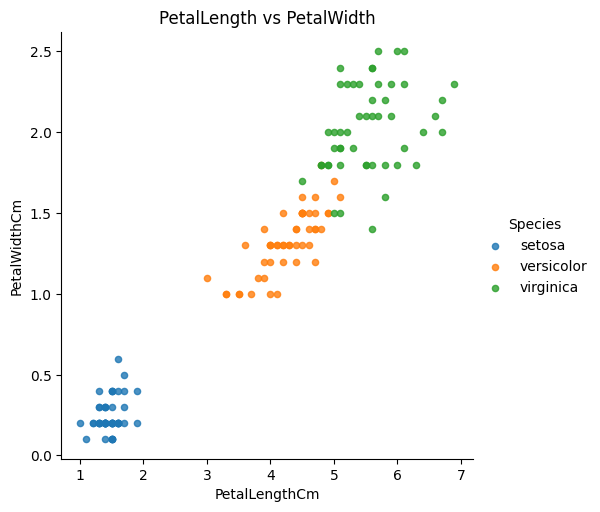

In [4]:
sns.lmplot(x = 'PetalLengthCm', y = 'PetalWidthCm', data = data, fit_reg = False, hue = "Species", scatter_kws = {"marker": "D", "s": 20})
plt.title('PetalLength vs PetalWidth')
plt.show()

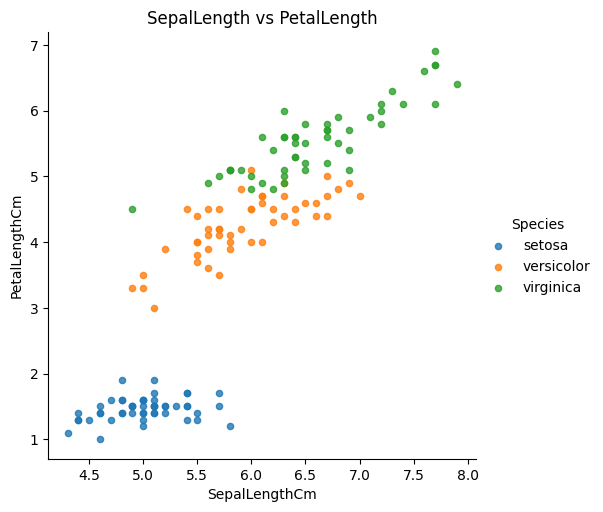

In [5]:
sns.lmplot(x = 'SepalLengthCm', y = 'PetalLengthCm', data = data, fit_reg = False, hue = "Species", scatter_kws = {"marker": "D", "s": 20})
plt.title('SepalLength vs PetalLength')
plt.show()

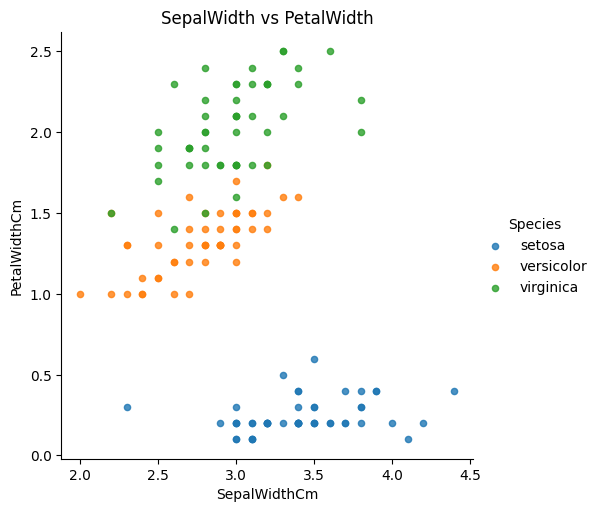

In [6]:
sns.lmplot(x = 'SepalWidthCm', y = 'PetalWidthCm', data = data, fit_reg = False, hue = "Species", scatter_kws = {"marker": "D", "s": 20})
plt.title('SepalWidth vs PetalWidth')
plt.show()

**Label Coding TV**

This can be done before the data split

In [7]:
print(data["Species"].unique())

['setosa' 'versicolor' 'virginica']


In [8]:
print(data["Species"].value_counts())

Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [9]:
data['Species'] = pd.factorize(data['Species'])[0]
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0


**Variable Assignment**

In [10]:
x = data.drop(columns = ['Id', 'Species'], axis = 1)
y = data['Species']

**Data Split**

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

**Standardization** 

It can be seen from above that the feature of the first dataset has 6 cm in Sepal Length, 3.4 cm in Sepal Width, 4.5 cm in Petal Length and 1.6 cm in Petal Width. However, the range of the dataset may be different. Therefore, in order to maintain a good accuracy, the feature of each dataset must be normalized to a range of 0-1 for processing.

Still, the model can be fitted using the not normalised (scaled) data, thus may be useful for large dataset.

In [12]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

**ANN**

In [13]:
from keras.models import Sequential 
from keras.layers import Dense, Dropout, Input 
from keras.utils import to_categorical

In [14]:
# Change the label to one hot vector

y_train = to_categorical(y_train, num_classes = 3)
y_test = to_categorical(y_test, num_classes = 3)
print("Shape of y_train", y_train.shape)
print("Shape of y_test", y_test.shape)

Shape of y_train (120, 3)
Shape of y_test (30, 3)


In [15]:
def fit_model(optimizer):
    model=Sequential()
    model.add(Input(shape = (4,)))
    model.add(Dense(256, kernel_initializer = 'uniform', activation = 'relu'))
    model.add(Dropout(0.2))
    model.add(Dense(128, kernel_initializer = 'uniform', activation = 'relu'))
    model.add(Dropout(0.2))
    model.add(Dense(64, kernel_initializer = 'uniform', activation = 'relu'))
    model.add(Dropout(0.2))
    model.add(Dense(3, activation = 'softmax'))
  
    model.compile(loss = 'categorical_crossentropy', optimizer = optimizer, metrics = ['accuracy'])
  
    history = model.fit(x_train, y_train, validation_data = (x_test, y_test), batch_size = 16, epochs = 100)
    
    print('Accuracy with', optimizer,'optimizer is :', model.evaluate(x_test, y_test)[1]*100)
    
    plt.plot(history.history['accuracy'], label = 'train')
    plt.plot(history.history['val_accuracy'], label = 'test')
    plt.legend(loc = 'best')
    plt.title('opt=' + optimizer)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.4975 - loss: 1.0958 - val_accuracy: 0.6333 - val_loss: 1.0931
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5390 - loss: 1.0938 - val_accuracy: 0.6333 - val_loss: 1.0904
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5896 - loss: 1.0904 - val_accuracy: 0.6333 - val_loss: 1.0883
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6480 - loss: 1.0897 - val_accuracy: 0.6333 - val_loss: 1.0868
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5914 - loss: 1.0883 - val_accuracy: 0.6333 - val_loss: 1.0853
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7369 - loss: 1.0847 - val_accuracy: 0.6333 - val_loss: 1.0838
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7286 - loss: 1.0847 - val_accuracy: 0.6333 - val_loss: 1.0823
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6525 - loss: 1.0835 - val_accuracy: 0.6333 - val_loss:

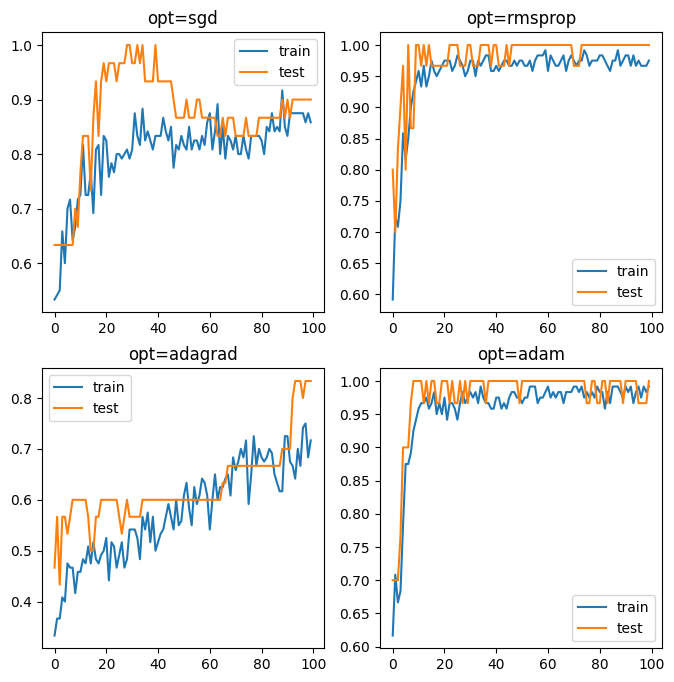

In [16]:
optimizers = ['sgd', 'rmsprop', 'adagrad', 'adam']
plt.figure(figsize = (8,8))
for i in range(len(optimizers)):
    # determine the plot number
    plot_no = 220 + (i+1)
    plt.subplot(plot_no)
    # fit model and plot learning curves for an optimizer
    fit_model(optimizers[i])
# show learning curves
plt.show()